In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import zipfile
import os

In [2]:
if not os.path.exists('data/dataset/Physical dataset/cleaned'):
    os.makedirs('data/dataset/Physical dataset/cleaned')

In [9]:
# Load data 
# ONLY FOR phy_att_4.csv the delmiter is ',' and utf-8 encoding
df_attack = pd.read_csv('data/dataset/Physical dataset/phy_att_4.csv', delimiter=',', header=0, encoding='utf-8')

In [5]:
print(df_attack.shape)
print(df_attack.columns)

(1717, 1)
Index(['Time,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8,Pump_1,Pump_2,Pump_3,Pump_4,Pump_5,Pump_6,Flow_sensor_1,Flow_sensor_2,Flow_sensor_3,Flow_sensor_4,Valv_1,Valv_2,Valv_3,Valv_4,Valv_5,Valv_6,Valv_7,Valv_8,Valv_9,Valv_10,Valv_11,Valv_12,Valv_13,Valv_14,Valv_15,Valv_16,Valv_17,Valv_18,Valv_19,Valv_20,Valv_21,Valv_22,Label_n,Label'], dtype='object')


In [135]:
df_attack.drop_duplicates(inplace=True)

In [136]:
print("Shape before dropna: ",df_attack.shape)
df_attack.dropna(inplace=True)
print("Shape after dropna: ",df_attack.shape)

Shape before dropna:  (1254, 43)
Shape after dropna:  (1254, 43)


# Almost zero NaN values in the physical attacks

In [137]:
def get_columns_info(column_name):
    print('Column name: ', column_name)
    print('Number of unique values in attack: ', df_attack[column_name].nunique())
    print('Number of missing values in attack: ', df_attack[column_name].isnull().sum())
    print('Number of values in attack: ', df_attack[column_name].count())
    print('Values in attack: ', df_attack[column_name].unique())
    print('Values count: ', df_attack[column_name].value_counts(normalize=True))

In [138]:
df_attack.dtypes

Time             object
Tank_1            int64
Tank_2            int64
Tank_3            int64
Tank_4            int64
Tank_5            int64
Tank_6            int64
Tank_7            int64
Tank_8            int64
Pump_1             bool
Pump_2             bool
Pump_3             bool
Pump_4             bool
Pump_5             bool
Pump_6             bool
Flow_sensor_1     int64
Flow_sensor_2     int64
Flow_sensor_3     int64
Flow_sensor_4     int64
Valv_1             bool
Valv_2             bool
Valv_3             bool
Valv_4             bool
Valv_5             bool
Valv_6             bool
Valv_7             bool
Valv_8             bool
Valv_9             bool
Valv_10            bool
Valv_11            bool
Valv_12            bool
Valv_13            bool
Valv_14            bool
Valv_15            bool
Valv_16            bool
Valv_17            bool
Valv_18            bool
Valv_19            bool
Valv_20            bool
Valv_21            bool
Valv_22            bool
Label_n         

# Columns description and analyses

1. Tank (int64): Contain value between 0 and 3427 for att_1.csv . No idea on what it means
2. Pump (bool): More False value for att_1.csv
3. Flow_sensor (int64): Flow_sensor_1/2/3 values are 0, 4000 or 100 but for the last one more than hundreds different value between 0 and 4789
4. Valv (bool): 22 columns, most of valv are false for all the rows espacially the first 9 valv are all set to false
5. Label_n (int64): 1 for attack 0 for normal 2/3 of normal (still more normal in the data) (0.85 for att_2)
6. Label: The name of the attack (normal, MITM, physical fault, DoS)

More normal than attack (same for network), no missing value. The columns are probably component of a machine and false and true can be if the component is affect ?


In [121]:
# only for att_2 rename Lable_n to Label_n 
# df_attack.rename(columns={'Lable_n':'Label_n'}, inplace=True)

In [154]:
get_columns_info('Label_n')

Column name:  Label_n
Number of unique values in attack:  2
Number of missing values in attack:  0
Number of values in attack:  1254
Values in attack:  [0 1]
Values count:  Label_n
0    0.726475
1    0.273525
Name: proportion, dtype: float64


In [ ]:
for i in range(1,23):
    print(df_attack['Valv_'+str(i)].value_counts(normalize=True))

In [155]:
# Clean data types
df_attack['Time'] = pd.to_datetime(df_attack['Time'], errors='coerce')

In [156]:
# Category encoding
df_attack['Label'] = df_attack['Label'].astype('category')

In [157]:
# bool encoding for Label_n True for 1 and False for 0
df_attack['Label_n'] = df_attack['Label_n'].astype('bool')

In [158]:
df_attack.dtypes

Time             datetime64[ns]
Tank_1                    int64
Tank_2                    int64
Tank_3                    int64
Tank_4                    int64
Tank_5                    int64
Tank_6                    int64
Tank_7                    int64
Tank_8                    int64
Pump_1                     bool
Pump_2                     bool
Pump_3                     bool
Pump_4                     bool
Pump_5                     bool
Pump_6                     bool
Flow_sensor_1             int64
Flow_sensor_2             int64
Flow_sensor_3             int64
Flow_sensor_4             int64
Valv_1                     bool
Valv_2                     bool
Valv_3                     bool
Valv_4                     bool
Valv_5                     bool
Valv_6                     bool
Valv_7                     bool
Valv_8                     bool
Valv_9                     bool
Valv_10                    bool
Valv_11                    bool
Valv_12                    bool
Valv_13 

In [159]:
# Save cleaned data
df_attack.to_csv('data/dataset/Physical dataset/cleaned/phy_att_3.csv', index=False)

<AxesSubplot:title={'center':'Tank_3'}, xlabel='Label_n'>

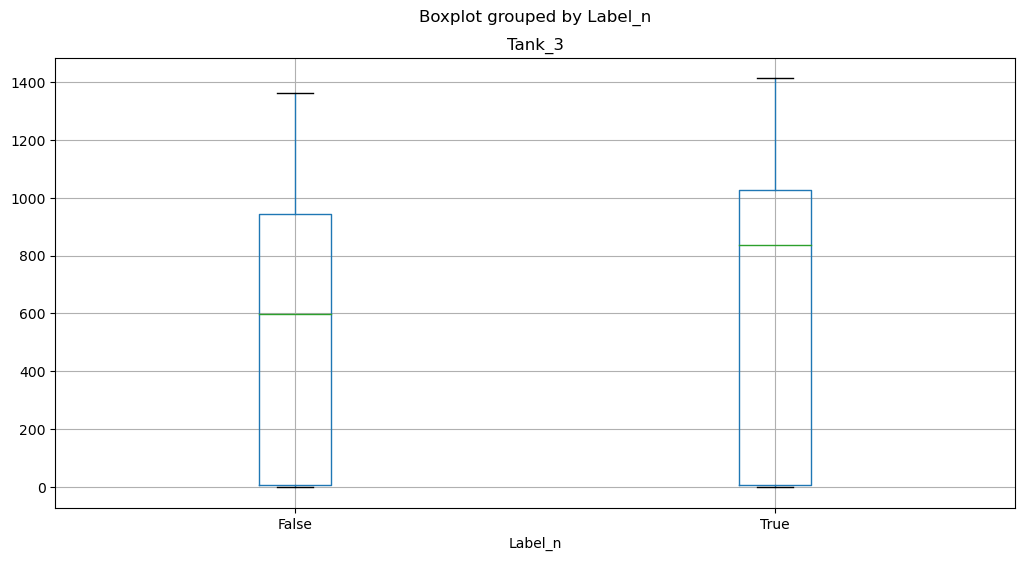

In [160]:
df_attack.describe()

# Plot boxplot

df_attack.boxplot(column='Tank_3', by='Label_n', figsize=(12, 6)) 

In [10]:
df_attack['Tank_3'].describe()

count    2420.000000
mean      922.677686
std       942.572849
min         0.000000
25%        73.250000
50%       747.500000
75%      1226.250000
max      3427.000000
Name: Tank_3, dtype: float64

In [15]:
# Plot scatter plot

fig = px.scatter(df_attack, x='Time', y=['Tank_3','Label_n'], color='Label')
fig.show()